<a href="https://colab.research.google.com/github/AnthonyMath1022/AnthonyMath1022/blob/main/Copy_of_Retail_Analysis_LSTM2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display
from google.colab import drive
drive.mount('/content/drive')

print('Loading data...')
train_path = '/content/drive/MyDrive/Reatilforecast/src/train.csv'
train_df = pd.read_csv(train_path, low_memory=True)
train_df['date'] = pd.to_datetime(train_df['date'])
pd.set_option('display.max_columns', 10)
display(train_df)


Mounted at /content/drive
Loading data...


/tmp/ipython-input-2959674660.py:9: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(train_path, low_memory=True)


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


In [ ]:
start_date = '2017-07-01'
end_date = '2017-12-31'

train_df = train_df[(train_df['date'] >= start_date) & (train_df['date'] <= end_date)]
pd.set_option('display.max_columns', 10)
display(train_df)
train_df.count()
train_df.isna().sum()


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
120642911,120642911,2017-07-01,1,99197,2.0,False
120642912,120642912,2017-07-01,1,103520,2.0,False
120642913,120642913,2017-07-01,1,103665,11.0,False
120642914,120642914,2017-07-01,1,105574,2.0,False
120642915,120642915,2017-07-01,1,105575,3.0,False
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


,0
id,0
date,0
store_nbr,0
item_nbr,0
unit_sales,0
onpromotion,0


In [ ]:
import pandas as pd

item_path = '/content/drive/MyDrive/Reatilforecast/src/items.csv'
store_path = '/content/drive/MyDrive/Reatilforecast/src/stores.csv'
oil_path = '/content/drive/MyDrive/Reatilforecast/src/oil.csv'

item = pd.read_csv(item_path)
store = pd.read_csv(store_path)
oil = pd.read_csv(oil_path )
oil = oil[(oil['date'] >= start_date) & (oil['date'] <= end_date)]

train_df = pd.merge(train_df,item,on='item_nbr',how='left')
train_df = pd.merge(train_df,store,on='store_nbr',how='left')
train_df.isna().sum()

,0
id,0
date,0
store_nbr,0
item_nbr,0
unit_sales,0
onpromotion,0
family,0
class,0
perishable,0
city,0


In [ ]:
import numpy as np

def most_frequent_sales(data, variable, N, all='TRUE'):


    # counts
    values, counts = np.unique(data[variable].to_numpy(), return_counts=True)

    # Ensure values and counts are 2D column vectors before stacking
    values_2d = values.reshape(-1, 1)
    counts_2d = counts.reshape(-1, 1)

    # Nx2 table: [value, count]
    labels_freq_pd = np.column_stack((values_2d, counts_2d))

    # sort by count desc
    labels_freq_pd = labels_freq_pd[np.argsort(labels_freq_pd[:, 1])[::-1]]

    # keep top N
    topN = labels_freq_pd[:N]
    main_labels = topN[:, 0] if all == 'False' else labels_freq_pd[:, 0]

    # raw labels (replace deprecated as_matrix)
    labels_raw_np = data[variable].to_numpy().reshape(-1, 1)

    # indices where label in main_labels (same style as your labels_filtered_index[0])
    labels_filtered_index = np.where(np.isin(labels_raw_np.ravel(), main_labels))

    return topN, labels_filtered_index

label_freq, labels_filtered_index = most_frequent_sales(train_df, 'item_nbr', 5, 'FALSE')
print("pd_train.shape=", labels_filtered_index[0].shape)

pd_train_filtered = train_df.loc[labels_filtered_index[0], :]
print("pd_train_filtered.shape = ", pd_train_filtered.shape)


pd_train.shape= (4854129,)
pd_train_filtered.shape =  (4854129, 13)


In [ ]:
pd_train_filtered  = pd_train_filtered.drop(['city','state','type','cluster','store_nbr','item_nbr','family','class','id'], axis = 1)

In [ ]:

dummy_variables = ['onpromotion','perishable']

for var in dummy_variables:
    dummy = pd.get_dummies(pd_train_filtered [var], prefix = var, drop_first = False).astype(int)
    pd_train_filtered  = pd.concat([pd_train_filtered ,dummy], axis = 1)

pd_train_filtered  = pd_train_filtered.drop(dummy_variables, axis = 1)


In [ ]:
import pandas as pd

# 1. Ensure your date columns are actual datetime objects
pd_train_filtered ['date'] = pd.to_datetime(pd_train_filtered ['date'])
oil['date'] = pd.to_datetime(oil['date'])

# 2. Generate the complete date range automatically
# pd.date_range replaces the manual loop and delta calculation
calendar = pd.DataFrame({
    'date': pd.date_range(start=train_df.date.min(), end=train_df.date.max())
})

# 3. Merge
oil = calendar.merge(oil, on='date', how='left')

In [ ]:
na_index_oil = oil[oil['dcoilwtico'].isnull() == True].index.values

#Define the index to use to apply the formala
na_index_oil_plus = na_index_oil.copy()
na_index_oil_minus = np.maximum(0, na_index_oil-1)

for i in range(len(na_index_oil)):
    k = 1
    while (na_index_oil[min(i+k,len(na_index_oil)-1)] == na_index_oil[i]+k):
        k += 1
    na_index_oil_plus[i] = min(len(oil)-1, na_index_oil_plus[i] + k )

#Apply the formula
for i in range(len(na_index_oil)):
    if (na_index_oil[i] == 0):
        oil.loc[na_index_oil[i], 'dcoilwtico'] = oil.loc[na_index_oil_plus[i], 'dcoilwtico']
    elif (na_index_oil[i] == len(oil)):
        oil.loc[na_index_oil[i], 'dcoilwtico'] = oil.loc[na_index_oil_minus[i], 'dcoilwtico']
    else:
        oil.loc[na_index_oil[i], 'dcoilwtico'] = (oil.loc[na_index_oil_plus[i], 'dcoilwtico'] + oil.loc[na_index_oil_minus[i], 'dcoilwtico'])/ 2

pd_train_filtered  = pd_train_filtered.merge(oil, left_on='date', right_on='date', how='left')


In [ ]:
pd_train_filtered.sample(10)

,date,unit_sales,onpromotion_False,onpromotion_True,perishable_0,perishable_1,dcoilwtico
4161258,2017-08-09,2.000,1,0,1,0,49.590
3065012,2017-07-29,5.957,1,0,0,1,49.965
4375163,2017-08-11,1.000,1,0,1,0,48.810
576666,2017-07-06,7.000,1,0,1,0,45.520
4410553,2017-08-11,3.000,1,0,1,0,48.810
1202115,2017-07-12,16.000,1,0,1,0,45.480
533996,2017-07-05,22.000,1,0,1,0,45.110
3273491,2017-07-31,1.000,1,0,1,0,50.210
3411472,2017-08-02,2.000,1,0,1,0,49.600
1441243,2017-07-14,1.000,1,0,1,0,46.530


In [ ]:
pd_train_filtered.count()

,0
date,4854129
unit_sales,4854129
onpromotion_False,4854129
onpromotion_True,4854129
perishable_0,4854129
perishable_1,4854129
dcoilwtico,4854129


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# --- CONFIGURATION ---
LOOKBACK = 7
HORIZON = 1
TOP_N = 10

# 1. Filter for Top 10 Items
# We use a wider date range (from Jan 2017) to ensure enough data for lookback and splitting.
local_start_date = '2017-01-01'

temp_base_df = pd.read_csv(train_path, low_memory=True)
temp_base_df['date'] = pd.to_datetime(temp_base_df['date'])
temp_base_df = temp_base_df[(temp_base_df['date'] >= local_start_date) & (temp_base_df['date'] <= end_date)].copy()

# Re-merge with item and store data
temp_item_df = pd.read_csv(item_path)
temp_store_df = pd.read_csv(store_path)
temp_base_df = pd.merge(temp_base_df, temp_item_df, on='item_nbr', how='left')
temp_base_df = pd.merge(temp_base_df, temp_store_df, on='store_nbr', how='left')

# Reload and merge Oil data (full range to cover Jan-July)
oil_full = pd.read_csv(oil_path)
oil_full['date'] = pd.to_datetime(oil_full['date'])
temp_base_df = pd.merge(temp_base_df, oil_full[['date', 'dcoilwtico']], on='date', how='left')

# Top 10 items
top_items = temp_base_df['item_nbr'].value_counts().head(TOP_N).index
pd_train_filtered = temp_base_df[temp_base_df['item_nbr'].isin(top_items)].copy()

# 2. Pivot the Data to Wide Format
# Sales Pivot
pivoted_sales = pd_train_filtered.pivot_table(
    index='date',
    columns='item_nbr',
    values='unit_sales',
    fill_value=0
)
pivoted_sales.columns = [f'sales_{i}' for i in pivoted_sales.columns]

# Promotion Pivot
if 'onpromotion' in pd_train_filtered.columns:
    pd_train_filtered['onpromotion'] = pd_train_filtered['onpromotion'].astype(int)
    pivoted_promo = pd_train_filtered.pivot_table(
        index='date',
        columns='item_nbr',
        values='onpromotion',
        fill_value=0
    )
    pivoted_promo.columns = [f'promo_{i}' for i in pivoted_promo.columns]
else:
    pivoted_promo = pd.DataFrame()

# Oil Data (Common Feature)
oil_series = pd_train_filtered.groupby('date')['dcoilwtico'].max()

# 3. Combine into one Wide Dataframe
combined = pd.concat([pivoted_sales, pivoted_promo, oil_series], axis=1)

# Fill gaps
combined = combined.ffill().bfill()

# Define targets and features
stock_cols = pivoted_sales.columns.tolist()
print(f"Target Columns ({len(stock_cols)}): {stock_cols}")
print(f"Total Features: {combined.shape[1]}")
print(f"Total Data Points (Days): {len(combined)}")

# --- TRAIN/TEST SPLIT ---
# Adjusted test_len to 16 days (typical for this dataset's horizon)
test_len = 30
trainval = combined.iloc[:-test_len]
test_data = combined.iloc[-test_len:]

val_len = int(len(trainval) * 0.2)
train_len = len(trainval) - val_len

train_data = trainval.iloc[:train_len]
val_data = trainval.iloc[train_len:]

print(f"Train size: {len(train_data)}, Val size: {len(val_data)}, Test size: {len(test_data)}")

# Scaling
feat_scaler = MinMaxScaler()
feat_scaler.fit(train_data.values)

train_scaled = feat_scaler.transform(train_data.values)
val_scaled = feat_scaler.transform(val_data.values)
test_scaled = feat_scaler.transform(test_data.values)

/tmp/ipython-input-2068341601.py:14: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_base_df = pd.read_csv(train_path, low_memory=True)


Target Columns (10): ['sales_222879', 'sales_261052', 'sales_265559', 'sales_314384', 'sales_323013', 'sales_364606', 'sales_502331', 'sales_1052563', 'sales_1157564', 'sales_1162382']
Total Features: 21
Total Data Points (Days): 227
Train size: 158, Val size: 39, Test size: 30


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, GaussianNoise, Bidirectional, LSTM, Dropout, TimeDistributed, Dense
!pip install keras-tuner
import keras_tuner as kt

n_in = LOOKBACK
n_out = HORIZON

def make_windows(arr, n_in, n_out, multi_step=True):
    X, y = [], []
    # Safety check for length
    if len(arr) < n_in + n_out:
        return np.array(X), np.array(y)

    for i in range(len(arr) - n_in - n_out + 1):
        X.append(arr[i : i + n_in])
        if multi_step:
            y.append(arr[i + n_in : i + n_in + n_out])
        else:
            y.append(arr[i + n_in + n_out - 1])
    return np.array(X), np.array(y)

# --- FIX: Concatenate History ---
# To predict the first day of validation, we need the last 'n_in' days of training as context.
# To predict the first day of testing, we need the last 'n_in' days of validation as context.
val_scaled_extended = np.concatenate((train_scaled[-n_in:], val_scaled))
test_scaled_extended = np.concatenate((val_scaled[-n_in:], test_scaled))

# Create windows using extended datasets
train_X, train_y = make_windows(train_scaled, n_in, n_out, multi_step=True)
val_X, val_y = make_windows(val_scaled_extended, n_in, n_out, multi_step=True)
test_X, test_y = make_windows(test_scaled_extended, n_in, n_out, multi_step=True)

print(f"Train shape: {train_X.shape}, Val shape: {val_X.shape}, Test shape: {test_X.shape}")

# Important: Slice y to only include the target columns (the first 10 columns)
# The features (promo, oil) are in X but we don't try to predict them.
num_targets = len(stock_cols)
train_y = train_y[:, :, :num_targets]
val_y = val_y[:, :, :num_targets]

# Only slice test_y if it's not empty
if len(test_y) > 0:
    test_y = test_y[:, :, :num_targets]

input_shape = (train_X.shape[1], train_X.shape[2])
output_shape = num_targets # This will be 10

# --- MODEL BUILDER ---
def build_model(hp):
    inputs = Input(shape=input_shape, name="inputs")
    x = GaussianNoise(0.01)(inputs)

    # LSTM Layers
    for layer in range(hp.Int("num_layers", 1, 3)):
        x = Bidirectional(LSTM(
            units=hp.Int("lstm_units_1", 32, 256, step=32), # Reduced max for speed
            activation='tanh',
            return_sequences=True
        ))(x)

    x = Dropout(hp.Float('dropout_1', 0.1, 0.5, step=0.05))(x)

    # Output Layer
    # We use TimeDistributed(Dense(10)) to output 10 predictions per time step
    x = TimeDistributed(Dense(output_shape))(x)

    # Slice to keep only the last 'n_out' steps (the horizon)
    x = x[:, -n_out:, :]

    model = tf.keras.Model(inputs, x)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")),
        loss="mse"
    )
    return model

# --- TUNER ---
import os
if not os.path.exists('my_dir'):
    os.makedirs('my_dir')

tuner = kt.BayesianOptimization(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=5,
    directory='my_dir',
    project_name='favorita_forecast',
    overwrite=True
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

tuner.search(
    train_X, train_y,
    epochs=1000, # Reduced for demonstration, increase for real training
    batch_size=64,
    validation_data=(val_X, val_y),
    callbacks=[stop_early]
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)
best_model.summary()

# Train final model
history = best_model.fit(
    train_X, train_y,
    epochs=100,
    batch_size=64,
    validation_data=(val_X, val_y),
    callbacks=[stop_early],
    verbose=1
)

Trial 10 Complete [00h 01m 35s]
val_loss: 0.028232352808117867

Best val_loss So Far: 0.01806868575513363
Total elapsed time: 00h 08m 47s


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 7, 21)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_1                │ (None, 7, 21)          │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 7, 448)         │       440,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 448)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 7, 10)          │         4,490 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_1 (GetItem)            │ (None, 1, 10)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 445,322 (1.70 MB)

 Trainable params: 445,322 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - loss: 0.1065 - val_loss: 0.0305
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0452 - val_loss: 0.0355
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0315 - val_loss: 0.0349
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0314 - val_loss: 0.0267
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0256 - val_loss: 0.0245
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0255 - val_loss: 0.0245
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0248 - val_loss: 0.0251
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0220 - val_loss: 0.0268
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0234 - val_loss: 0.0262
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0212 - val_loss: 0.0239
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0196 - val_loss: 0.0227
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0208 - val_l

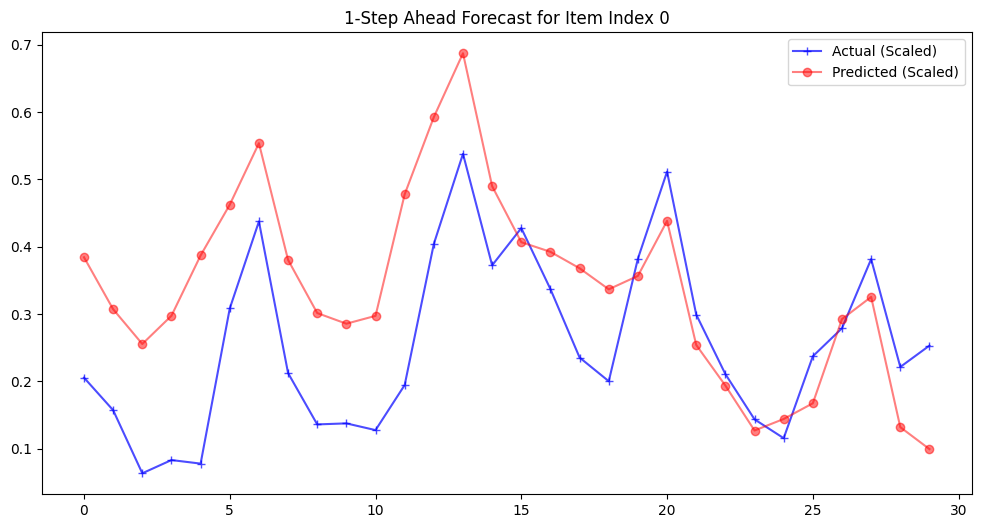

In [ ]:
import matplotlib.pyplot as plt

# Select the first item to plot (index 0)
item_idx = 0

predictions = best_model.predict(test_X, verbose=0)
# Extract the 1-step ahead forecast (index 0 in the time dimension)
# Shape becomes: (Samples,)
actuals = test_y[:, 0, item_idx]
preds = predictions[:, 0, item_idx]

plt.figure(figsize=(12, 6))
plt.plot(actuals, '+-', color='blue', alpha=0.7, label='Actual (Scaled)')
# Fix: Removed redundant color='red' since 'ro-' already specifies red
plt.plot(preds, 'ro-', alpha=0.5, label='Predicted (Scaled)')
plt.title(f'1-Step Ahead Forecast for Item Index {item_idx}')
plt.legend()
plt.show()

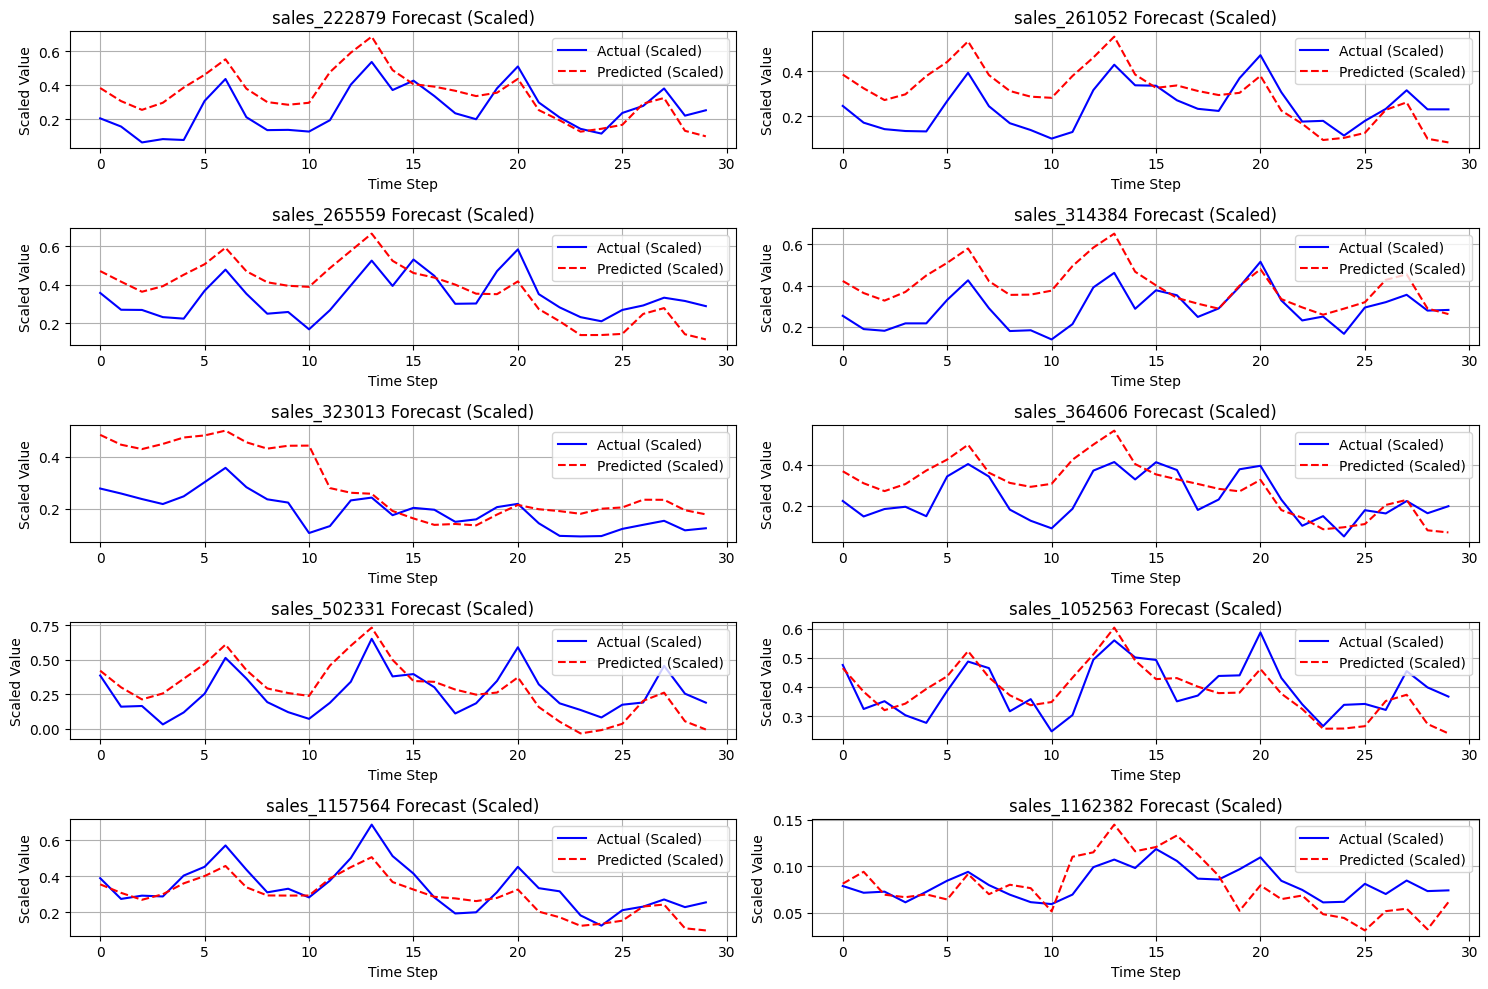


--- Metrics per Target Item (Test Set, Original Scale) ---

Metrics for sales_222879:
MSE: 12.3619
MAE: 2.9728
RMSE: 3.5160
MAPE: 23.5821%
MSPE: 12.3619
sqrt MSPE: 3.5160
R2: -0.2671

Metrics for sales_261052:
MSE: 78.5186
MAE: 7.6698
RMSE: 8.8611
MAPE: 34.7056%
MSPE: 78.5186
sqrt MSPE: 8.8611
R2: -0.7260

Metrics for sales_265559:
MSE: 143.2973
MAE: 10.9814
RMSE: 11.9707
MAPE: 28.2547%
MSPE: 143.2973
sqrt MSPE: 11.9707
R2: -0.7238

Metrics for sales_314384:
MSE: 106.4776
MAE: 8.3488
RMSE: 10.3188
MAPE: 27.7430%
MSPE: 106.4776
sqrt MSPE: 10.3188
R2: -1.3371

Metrics for sales_323013:
MSE: 55.6143
MAE: 5.9996
RMSE: 7.4575
MAPE: 44.0211%
MSPE: 55.6143
sqrt MSPE: 7.4575
R2: -3.3069

Metrics for sales_364606:
MSE: 45.0684
MAE: 5.7900
RMSE: 6.7133
MAPE: 16.5089%
MSPE: 45.0684
sqrt MSPE: 6.7133
R2: -0.1903

Metrics for sales_502331:
MSE: 55.6475
MAE: 6.6191
RMSE: 7.4597
MAPE: 18.7637%
MSPE: 55.6475
sqrt MSPE: 7.4597
R2: -0.0325

Metrics for sales_1052563:
MSE: 14.8989
MAE: 3.2664
RMSE: 3.85

In [ ]:
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import r2_score # Import r2_score

# --- Plotting section ---
plt.figure(figsize=(15, 10))
# Iterate only over the target columns (sales items)
for i in range(num_targets):
    col_name = stock_cols[i] # Get the name of the target column
    plt.subplot(5, 2, i + 1)
    # Use test_y and predictions directly, extracting the i-th target and the first horizon step
    plt.plot(test_y[:, 0, i], label='Actual (Scaled)', color='blue')
    plt.plot(predictions[:, 0, i], label='Predicted (Scaled)', color='red', linestyle='--')
    plt.title(f'{col_name} Forecast (Scaled)')
    plt.xlabel('Time Step')
    plt.ylabel('Scaled Value')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()


# --- Metrics Calculation Section ---

# Helper functions for metrics
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mean_squart_perdiction_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(((y_true - y_pred))**2)

# Inverse transform predictions and actuals for original scale metrics
# The scaler was fitted on the full feature set (21 features).
# We need to create dummy arrays with the full feature dimension for inverse_transform.

total_features = train_scaled.shape[1] # Corrected from train_scaled.shape[2]

# Create placeholder arrays for the full feature space
test_y_full_dim = np.zeros((test_y.shape[0], test_y.shape[1], total_features))
predictions_full_dim = np.zeros((predictions.shape[0], predictions.shape[1], total_features))

# Populate the target (sales) columns with actual values and predictions
test_y_full_dim[:, :, :num_targets] = test_y
predictions_full_dim[:, :, :num_targets] = predictions

# Reshape to 2D for inverse_transform: (samples * horizon, total_features)
test_y_inv_reshaped = test_y_full_dim.reshape(-1, total_features)
predictions_inv_reshaped = predictions_full_dim.reshape(-1, total_features)

# Inverse transform
test_y_inv_scaled = feat_scaler.inverse_transform(test_y_inv_reshaped)
predictions_inv_scaled = feat_scaler.inverse_transform(predictions_inv_reshaped)

# Fix: Use test_y.shape[0] for reshaping test_y_inv
test_y_inv = test_y_inv_scaled.reshape(test_y.shape[0], HORIZON, total_features)[:, :, :num_targets]
predictions_inv = predictions_inv_scaled.reshape(predictions.shape[0], HORIZON, total_features)[:, :, :num_targets]


# Metrics for each individual target item
print("\n--- Metrics per Target Item (Test Set, Original Scale) ---") # Changed from Validation Set
for i in range(num_targets):
    col_name = stock_cols[i]
    print(f"\nMetrics for {col_name}:")
    # Use the 0th index for the horizon since HORIZON is 1
    y_true_item = test_y_inv[:, 0, i]
    y_pred_item = predictions_inv[:, 0, i]

    print(f'MSE: {metrics.mean_squared_error(y_true_item, y_pred_item):.4f}')
    print(f'MAE: {metrics.mean_absolute_error(y_true_item, y_pred_item):.4f}')
    print(f'RMSE: {np.sqrt(metrics.mean_squared_error(y_true_item, y_pred_item)):.4f}')
    # Ensure y_true_item is not zero for MAPE
    if np.any(y_true_item == 0):
        print('MAPE: Not calculated due to zero values in actuals')
    else:
        print(f'MAPE: {mean_absolute_percentage_error(y_true_item, y_pred_item):.4f}%')
    print(f'MSPE: {mean_squart_perdiction_error(y_true_item, y_pred_item):.4f}')
    print(f'sqrt MSPE: {np.sqrt(mean_squart_perdiction_error(y_true_item, y_pred_item)):.4f}')
    print(f'R2: {r2_score(y_true_item, y_pred_item):.4f}')

# Overall metrics (Flattened across all target items and horizon steps for combined metrics)
print("\n--- Overall Metrics (Test Set, Original Scale) ---") # Changed from Validation Set

# Flatten the target dimension for overall metrics
# Fix: Use test_y_inv instead of val_y_inv for consistency with calculations on test_data
val_y_inv_flat_targets = test_y_inv.reshape(-1, num_targets)
predictions_inv_flat_targets = predictions_inv.reshape(-1, num_targets)

# Flatten completely for single overall scores
y_true_overall = val_y_inv_flat_targets.flatten()
y_pred_overall = predictions_inv_flat_targets.flatten()

print(f'MSE: {metrics.mean_squared_error(y_true_overall, y_pred_overall):.4f}')
print(f'MAE: {metrics.mean_absolute_error(y_true_overall, y_pred_overall):.4f}')
print(f'RMSE: {np.sqrt(metrics.mean_squared_error(y_true_overall, y_pred_overall)):.4f}')
if np.any(y_true_overall == 0):
    print('MAPE: Not calculated due to zero values in actuals')
else:
    print(f'MAPE: {mean_absolute_percentage_error(y_true_overall, y_pred_overall):.4f}%')
print(f'MSPE: {mean_squart_perdiction_error(y_true_overall, y_pred_overall):.4f}')
print(f'sqrt MSPE: {np.sqrt(mean_squart_perdiction_error(y_true_overall, y_pred_overall)):.4f}')
print(f'R2: {r2_score(y_true_overall, y_pred_overall):.4f}')

In [ ]:
def numpy_normalised_quantile_loss(y, y_pred, quantile):
  """Computes normalised quantile loss for numpy arrays.

  Uses the q-Risk metric as defined in the "Training Procedure" section of the
  main TFT paper.

  Args:
    y: Targets
    y_pred: Predictions
    quantile: Quantile to use for loss calculations (between 0 & 1)

  Returns:
    Float for normalised quantile loss.
  """
  prediction_underflow = y - y_pred
  weighted_errors = quantile * np.maximum(prediction_underflow, 0.) \
      + (1. - quantile) * np.maximum(-prediction_underflow, 0.)

  quantile_loss = weighted_errors.mean()
  normaliser = np.abs(y).mean() # Corrected line: use np.abs for numpy arrays

  return 2 * quantile_loss / normaliser


q_risk = numpy_normalised_quantile_loss(y_true_overall, y_pred_overall,0.9)
print(q_risk)

0.21465699952797407
